In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer  # obbligatorio per IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import LabelEncoder
from matplotlib import pyplot as plt
import seaborn as sns

# Imputazione valori mancanti

In [2]:
# 1. Caricamento e Preparazione
df = pd.read_csv('cmi_internet_da_classificare.csv')
ids = df['id']

In [3]:
df = df.drop(columns=['id', 'Physical-BMI'])
pciat_cols = df.columns[df.columns.str.contains('PCIAT')]
df = df.drop(columns=pciat_cols)

In [4]:
y = df['sii']
X = df.drop(columns=['sii'])

In [5]:
# 2. Separazione Colonne
numeric_cat_cols = [
    'FGC-FGC_CU_Zone', 'FGC-FGC_GSND_Zone', 'FGC-FGC_PU_Zone', 
    'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL_Zone', 
    'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num', 
    'PreInt_EduHx-computerinternet_hoursday'
]
string_cat_cols = X.select_dtypes(include=['object']).columns.tolist()
cat_cols = string_cat_cols + numeric_cat_cols
cont_cols = [col for col in X.columns if col not in cat_cols]

assert all(c in X.columns for c in numeric_cat_cols), "Colonna mancante!"
assert all(c in X.columns for c in string_cat_cols), "Colonna mancante!"
assert all(c in X.columns for c in cat_cols), "Colonna mancante!"
assert all(c in X.columns for c in cont_cols), "Colonna mancante!"

In [6]:
# Split Train-Test
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(X, y, ids, test_size=0.2, random_state=42)

In [7]:
# --- FASE 1: IMPUTAZIONE VARIABILI CONTINUE (IterativeImputer) ---
# Scaliamo prima dello scaling: il BayesianRidge sottostante ne beneficia
scaler = StandardScaler()
X_train_cont_scaled = pd.DataFrame(scaler.fit_transform(X_train[cont_cols]), columns=cont_cols, index=X_train.index)
X_test_cont_scaled = pd.DataFrame(scaler.transform(X_test[cont_cols]), columns=cont_cols, index=X_test.index)

In [8]:
# IterativeImputer: a ogni iterazione, ogni colonna viene imputata
# usando TUTTE le altre come predittori (regressione BayesianRidge).
# Converge dopo max_iter passaggi — molto più ricco del KNNImputer.
from sklearn.neighbors import KNeighborsRegressor

# Usiamo 5 vicini (puoi variare n_neighbors per vedere se migliora)
knn_estimator = KNeighborsRegressor(n_neighbors=5)
cont_imputer = IterativeImputer(
    estimator=knn_estimator,
    max_iter=10,
    random_state=42
)

X_train_cont_imp = pd.DataFrame(cont_imputer.fit_transform(X_train_cont_scaled), columns=cont_cols, index=X_train.index)
X_test_cont_imp = pd.DataFrame(cont_imputer.transform(X_test_cont_scaled), columns=cont_cols, index=X_test.index)

c:\Users\giber\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [9]:
# Riportiamo le continue alle unità di misura originali
X_train_cont_final = pd.DataFrame(scaler.inverse_transform(X_train_cont_imp), columns=cont_cols, index=X_train.index)
X_test_cont_final = pd.DataFrame(scaler.inverse_transform(X_test_cont_imp), columns=cont_cols, index=X_test.index)

In [10]:
# --- FASE 2: IMPUTAZIONE VARIABILI CATEGORICHE (KNN Classificatore Iterativo) ---
X_train_cat_final = X_train[cat_cols].copy()
X_test_cat_final = X_test[cat_cols].copy()

# Ordine di imputazione: prima le colonne con meno valori mancanti
cat_missing_counts = X_train_cat_final.isna().sum()
cat_cols_ordered = cat_missing_counts.sort_values().index.tolist()

# Dizionario per salvare gli encoder (uno per colonna categorica)
label_encoders = {}

for col in cat_cols_ordered:

    train_has_data = X_train_cat_final[col].notna()
    train_is_missing = X_train_cat_final[col].isna()

    # Colonne categoriche già imputate (senza buchi) da usare come feature aggiuntive
    already_imputed = [c for c in cat_cols_ordered if c != col and X_train_cat_final[c].isna().sum() == 0]

    # Encoding delle categoriche già imputate → numeri per sklearn
    already_imputed_train_enc = pd.DataFrame(index=X_train_cat_final.index)
    already_imputed_test_enc  = pd.DataFrame(index=X_test_cat_final.index)

    for c in already_imputed:
        if c not in label_encoders:
            le = LabelEncoder()
            le.fit(X_train_cat_final[c])  # fit solo su train
            label_encoders[c] = le
        le = label_encoders[c]
        already_imputed_train_enc[c] = le.transform(X_train_cat_final[c])
        already_imputed_test_enc[c]  = le.transform(X_test_cat_final[c])

    # Feature = continue scalate + categoriche già imputate (ora codificate)
    X_train_features = pd.concat([X_train_cont_imp, already_imputed_train_enc], axis=1)
    X_test_features  = pd.concat([X_test_cont_imp,  already_imputed_test_enc],  axis=1)

    # -- GESTIONE TRAIN --
    if train_is_missing.sum() > 0:
        knn_clf = KNeighborsClassifier(n_neighbors=5)
        knn_clf.fit(X_train_features[train_has_data], X_train_cat_final.loc[train_has_data, col])
        X_train_cat_final.loc[train_is_missing, col] = knn_clf.predict(X_train_features[train_is_missing])

    # -- GESTIONE TEST --
    test_is_missing = X_test_cat_final[col].isna()
    if test_is_missing.sum() > 0:
        knn_clf = KNeighborsClassifier(n_neighbors=5)
        knn_clf.fit(X_train_features, X_train_cat_final[col])
        X_test_cat_final.loc[test_is_missing, col] = knn_clf.predict(X_test_features[test_is_missing])

In [11]:
# --- FASE 3: RICOSTRUZIONE DATASET FINALE ---
train_final = pd.concat([id_train, X_train_cat_final, X_train_cont_final, y_train], axis=1)
test_final = pd.concat([id_test, X_test_cat_final, X_test_cont_final, y_test], axis=1)

df_final = pd.concat([train_final, test_final], axis=0)

# Calcolo BMI
df_final['Physical-BMI'] = (df_final['Physical-Weight'] * 703) / (df_final['Physical-Height'] ** 2)

# Riordino Colonne
cols = df_final.columns.tolist()
for c in ['id', 'Physical-BMI', 'sii']: cols.remove(c)
cols.insert(0, 'id')
cols.insert(cols.index('Physical-Weight') + 1, 'Physical-BMI')
cols.append('sii')
df_final = df_final[cols]
df_final.sort_values('id', inplace=True)

# Arrotondamento (solo per le continue, le categoriche sono già esatte!)
for col in cont_cols + ['Physical-BMI']:
    if (df_final[col] % 1 != 0).any(): 
        df_final[col] = df_final[col].round(2)

In [12]:
df_final

,id,Basic_Demos-Enroll_Season,CGAS-Season,Physical-Season,Fitness_Endurance-Season,FGC-Season,BIA-Season,PAQ_A-Season,PAQ_C-Season,SDS-Season,...,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-PAQ_A_Total,PAQ_C-PAQ_C_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,sii
0,0,Fall,Winter,Fall,Spring,Fall,Fall,Winter,Spring,Winter,...,24.43,8.90,38.92,19.54,32.69,2.01,2.42,42.0,57.4,2.0
1,1,Summer,Summer,Fall,Spring,Fall,Winter,Winter,Fall,Fall,...,21.04,14.97,39.45,15.41,27.06,2.01,2.34,46.0,64.0,0.0
2,2,Summer,Fall,Fall,Fall,Fall,Summer,Winter,Summer,Fall,...,26.68,14.84,57.00,25.37,44.99,2.00,2.17,38.0,54.0,0.0
3,3,Winter,Fall,Summer,Summer,Summer,Summer,Winter,Winter,Summer,...,30.40,16.78,58.93,26.48,46.00,2.00,2.45,31.0,45.0,1.0
4,4,Spring,Summer,Spring,Spring,Summer,Summer,Summer,Spring,Spring,...,28.86,16.44,57.00,27.42,44.99,1.04,2.54,40.8,57.4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,Spring,Spring,Fall,Fall,Summer,Fall,Winter,Spring,Summer,...,20.82,12.38,37.15,19.31,31.58,2.00,3.00,38.5,55.0,0.0
8456,8456,Winter,Spring,Winter,Winter,Summer,Spring,Winter,Winter,Winter,...,22.69,16.57,52.93,22.98,36.48,2.00,3.00,40.2,55.0,1.0
8457,8457,Winter,Winter,Winter,Fall,Winter,Summer,Winter,Spring,Spring,...,30.58,15.16,50.81,31.59,35.11,2.00,2.00,36.0,49.2,0.0
8458,8458,Fall,Summer,Spring,Spring,Fall,Spring,Winter,Summer,Fall,...,30.39,25.25,73.15,46.47,57.53,2.00,2.00,37.3,51.5,2.0


In [13]:
df

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,Fall,5,0,Winter,51.0,Fall,46.00,50.8,26.00,NaN,...,Winter,NaN,NaN,NaN,NaN,NaN,NaN,Fall,3.0,2.0
1,Summer,9,0,NaN,NaN,Fall,48.00,46.0,22.00,75.0,...,Winter,2.01,Fall,2.340,Fall,46.0,64.0,Summer,0.0,0.0
2,Summer,10,1,Fall,71.0,Fall,56.50,75.6,NaN,65.0,...,NaN,NaN,Summer,2.170,Fall,38.0,54.0,Summer,2.0,0.0
3,Winter,9,0,Fall,71.0,Summer,56.00,81.6,26.00,60.0,...,NaN,NaN,Winter,2.451,Summer,31.0,45.0,Winter,0.0,1.0
4,Spring,18,1,Summer,65.0,NaN,NaN,77.0,26.00,68.0,...,Summer,1.04,Spring,NaN,NaN,NaN,NaN,Spring,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,Spring,7,1,Spring,NaN,Fall,46.07,49.0,22.25,58.5,...,Winter,NaN,Spring,3.000,Summer,38.5,55.0,Spring,0.0,0.0
8456,Winter,10,1,Spring,69.5,Winter,56.13,47.8,28.50,66.0,...,Winter,2.00,Winter,3.000,NaN,NaN,NaN,Winter,0.0,1.0
8457,Winter,10,1,Winter,70.0,Winter,49.56,47.2,NaN,63.5,...,NaN,NaN,NaN,2.000,NaN,NaN,NaN,Spring,2.0,0.0
8458,Fall,15,1,NaN,55.5,Spring,63.79,99.5,31.10,NaN,...,NaN,2.00,Summer,2.000,NaN,NaN,NaN,Fall,1.0,2.0


In [14]:
# Carico i due dataset (originale con i buchi e finale imputato con il doppio modello)
try:
    df_orig = pd.read_csv('cmi_internet_da_classificare.csv')
    df_imp = df_final.copy()

    print("=== TEST 1: COMPLETEZZA DEI DATI (Sanity Check) ===")
    nans = df_imp.isna().sum().sum()
    print(f"Valori mancanti totali nel dataset finale: {nans}")

    print("=== TEST 2: INTEGRITÀ DELLE CATEGORIE (La prova del 9 sulla Moda) ===")
    col_cat = 'BIA-BIA_Activity_Level_num'
    val_orig = sorted([v for v in df_orig[col_cat].unique() if pd.notna(v)])
    val_imp = sorted(df_imp[col_cat].unique())
    print(f"Valori ammessi nel dataset Originale : {val_orig}")
    print(f"Valori presenti nel dataset Imputato : {val_imp}")
    if set(val_orig) == set(val_imp):
        print("-> RISULTATO: SUCCESSO! Nessun decimale ibrido (es. 1.8 o 2.4). Sono stati inseriti solo livelli puri.")

    print("=== TEST 3: STABILITÀ DEI VALORI CONTINUI (La prova sulla Media) ===")
    cont_cols_test = ['Physical-Height', 'Physical-Weight', 'Physical-HeartRate']
    for c in cont_cols_test:
        orig_mean = df_orig[c].mean()
        orig_std = df_orig[c].std()
        imp_mean = df_imp[c].mean()
        imp_std = df_imp[c].std()
        print(f"[{c}]")
        print(f"  Originale -> Media: {orig_mean:.2f} | Dev.Std: {orig_std:.2f}")
        print(f"  Imputato  -> Media: {imp_mean:.2f} | Dev.Std: {imp_std:.2f}")
        print(f"  Differenza-> Media: {imp_mean-orig_mean:.2f}")

    print("=== TEST 4: MANTENIMENTO DELLE PROPORZIONI (Testuali) ===")
    cat_col_text = 'CGAS-Season'
    prop_orig = df_orig[cat_col_text].value_counts(normalize=True) * 100
    prop_imp = df_imp[cat_col_text].value_counts(normalize=True) * 100
    df_prop = pd.DataFrame({'Originale (%)': prop_orig, 'Imputato (%)': prop_imp}).round(1)
    print(df_prop)
    
except Exception as e:
    print(f"Errore: {e}")

=== TEST 1: COMPLETEZZA DEI DATI (Sanity Check) ===
Valori mancanti totali nel dataset finale: 0
=== TEST 2: INTEGRITÀ DELLE CATEGORIE (La prova del 9 sulla Moda) ===
Valori ammessi nel dataset Originale : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
Valori presenti nel dataset Imputato : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
-> RISULTATO: SUCCESSO! Nessun decimale ibrido (es. 1.8 o 2.4). Sono stati inseriti solo livelli puri.
=== TEST 3: STABILITÀ DEI VALORI CONTINUI (La prova sulla Media) ===
[Physical-Height]
  Originale -> Media: 57.19 | Dev.Std: 7.37
  Imputato  -> Media: 57.11 | Dev.Std: 7.16
  Differenza-> Media: -0.08
[Physical-Weight]
  Originale -> Media: 85.33 | Dev.Std: 39.47
  Imputato  -> Media: 84.77 | Dev.Std: 37.96
  Differenza-> Media: -0.56
[Physical-HeartRate]
  Originale -> Media: 81.89 | Dev.Std: 11.38
  Imputato  -> Media: 81.86 | Dev.Std: 10.83
  Differenza-> Media: -0.04
==

In [15]:
df_final.isna().sum()

id                                        0
Basic_Demos-Enroll_Season                 0
CGAS-Season                               0
Physical-Season                           0
Fitness_Endurance-Season                  0
FGC-Season                                0
BIA-Season                                0
PAQ_A-Season                              0
PAQ_C-Season                              0
SDS-Season                                0
PreInt_EduHx-Season                       0
FGC-FGC_CU_Zone                           0
FGC-FGC_GSND_Zone                         0
FGC-FGC_PU_Zone                           0
FGC-FGC_SRL_Zone                          0
FGC-FGC_SRR_Zone                          0
FGC-FGC_TL_Zone                           0
BIA-BIA_Activity_Level_num                0
BIA-BIA_Frame_num                         0
PreInt_EduHx-computerinternet_hoursday    0
Basic_Demos-Age                           0
Basic_Demos-Sex                           0
CGAS-CGAS_Score                 

<Figure size 800x1000 with 0 Axes>

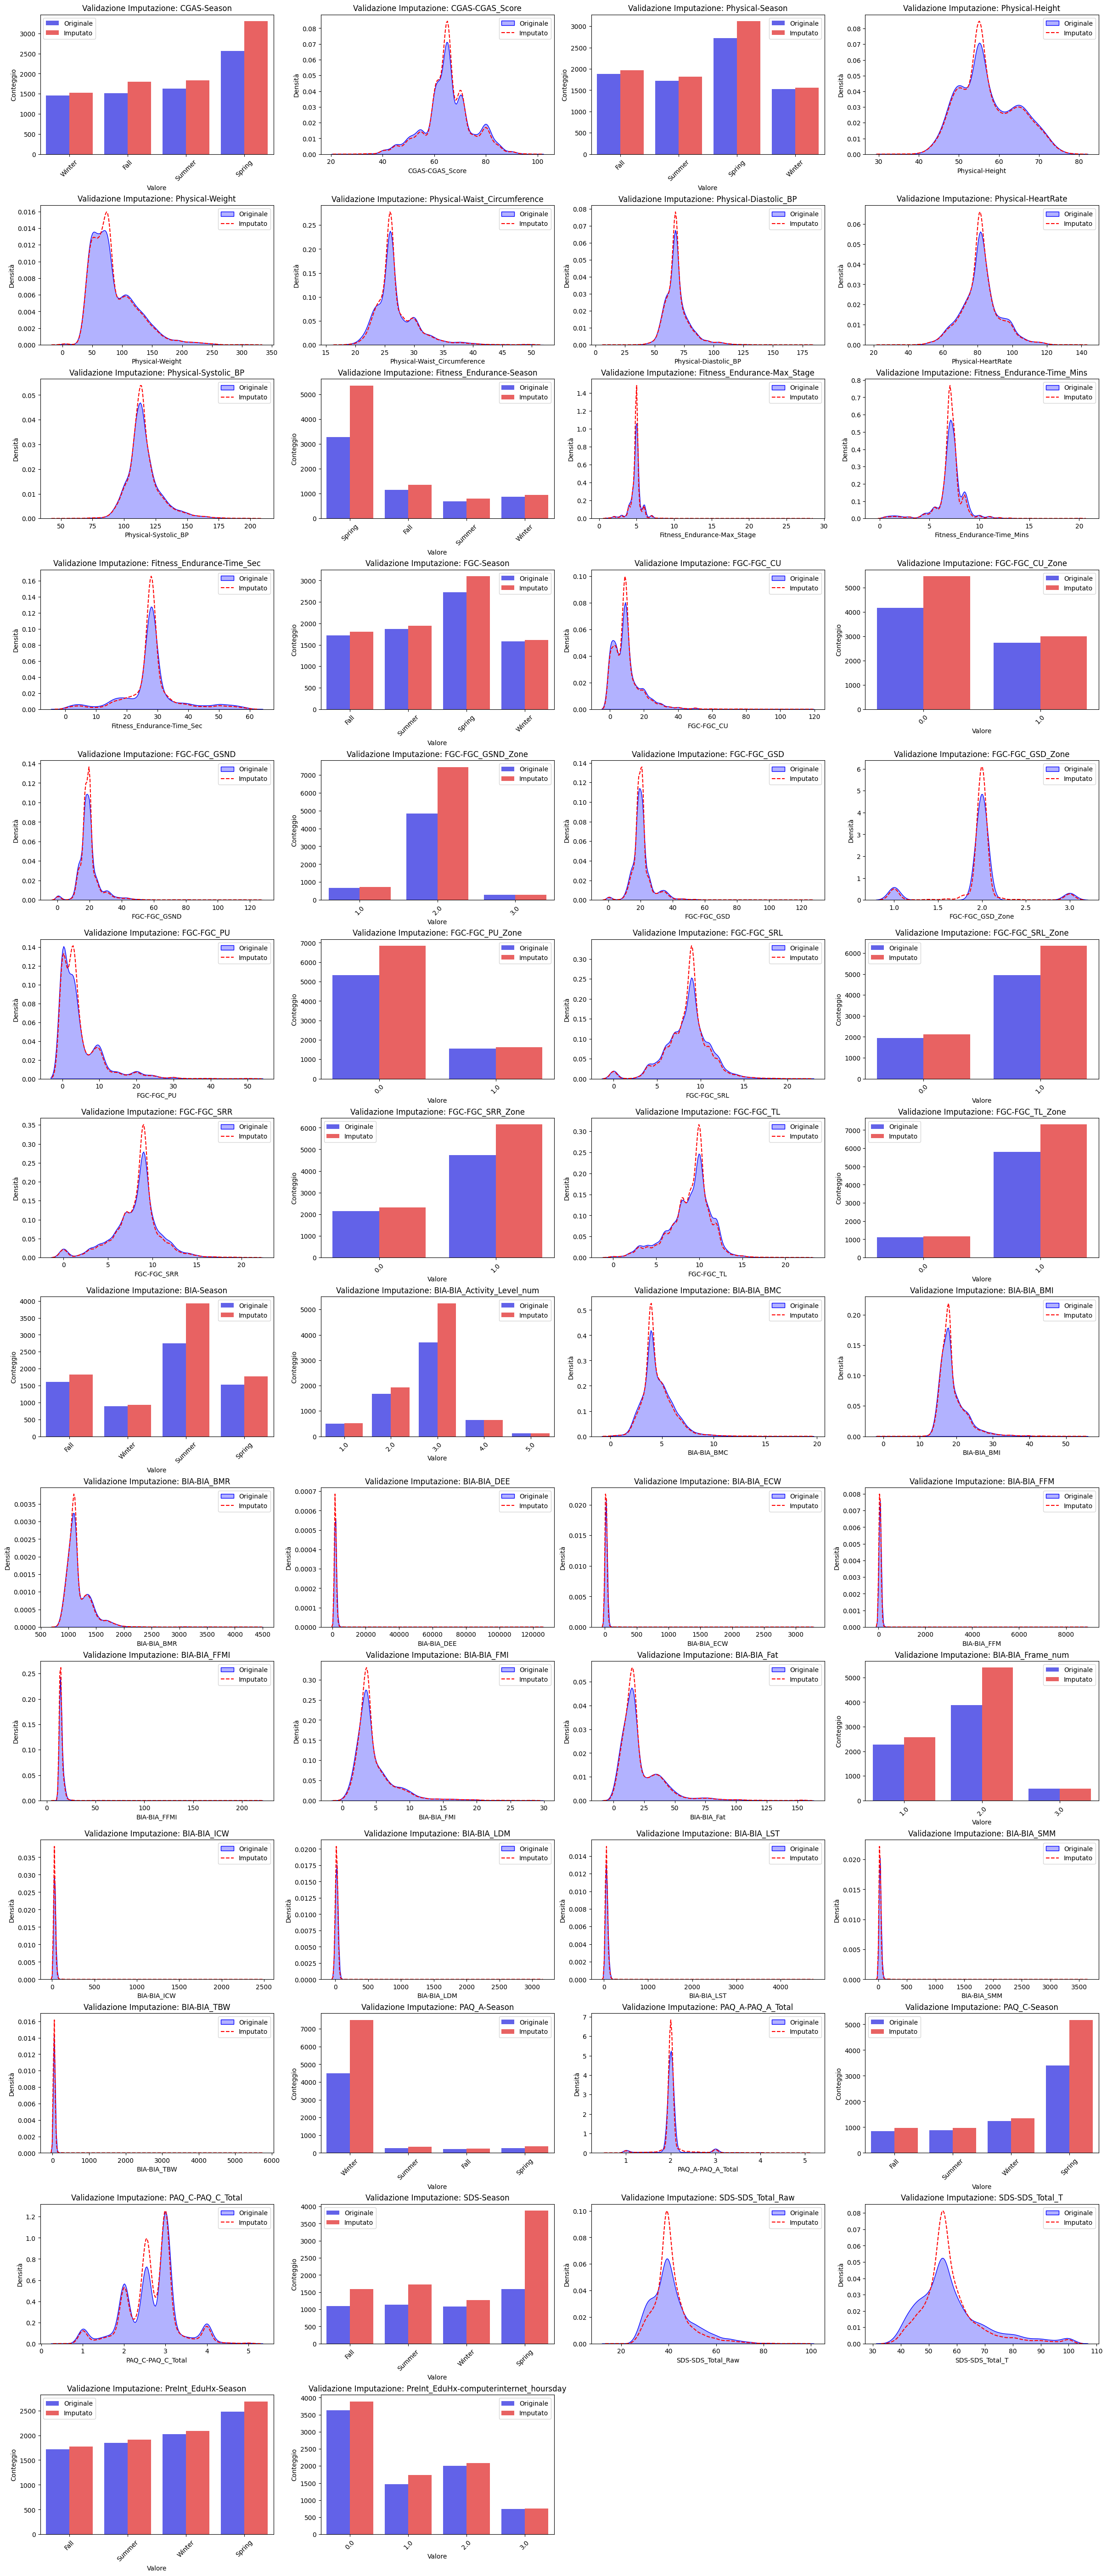

In [16]:
cols_with_nan = [col for col in df.columns if df[col].isnull().any()]
plt.figure(figsize=(8, 10))
ncols = 4
nrows = int(np.ceil(len(cols_with_nan) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4), constrained_layout=True)
axes = axes.flatten()

for idx, col in enumerate(cols_with_nan):
    ax = axes[idx]
    if df_final[col].dtype != 'object' and df_final[col].nunique() > 10:
        sns.kdeplot(df[col].dropna(), label='Originale', color='blue', fill=True, alpha=0.3, ax=ax)
        sns.kdeplot(df_final[col], label='Imputato', color='red', linestyle='--', ax=ax)
        ax.set_ylabel('Densità')
    else:
        df_comp = pd.DataFrame({
            'Valore': pd.concat([df[col].dropna(), df_final[col]]),
            'Tipo': ['Originale'] * len(df[col].dropna()) + ['Imputato'] * len(df_final[col])
        })
        sns.countplot(data=df_comp, x='Valore', hue='Tipo', palette=['blue', 'red'], alpha=0.7, ax=ax)
        ax.set_ylabel('Conteggio')
        for label in ax.get_xticklabels():
            label.set_rotation(45)

    ax.set_title(f'Validazione Imputazione: {col}')
    ax.legend()

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

In [17]:
#Aggiungo le colonne a cui fare una trasformazione logaritmica (quelle con distribuzione molto asimmetrica)
cols_to_log = ['Fitness_Endurance-Max_Stage','FGC-FGC_CU','FGC-FGC_GSND','BIA-BIA_DEE','BIA-BIA_ECW','BIA-BIA_FFM','BIA-BIA_FFMI','BIA-BIA_ICW','BIA-BIA_LDM','BIA-BIA_LST','BIA-BIA_SMM','BIA-BIA_TBW']

In [18]:
for col in cols_to_log:
    # Assicurati che non ci siano valori negativi prima di procedere
    if (df_final[col] < 0).any():
        print(f"Attenzione: la colonna {col} contiene valori negativi. Il logaritmo non è applicabile direttamente.")
    else:
        df_final[col] = np.log1p(df_final[col])

<Figure size 1200x1800 with 0 Axes>

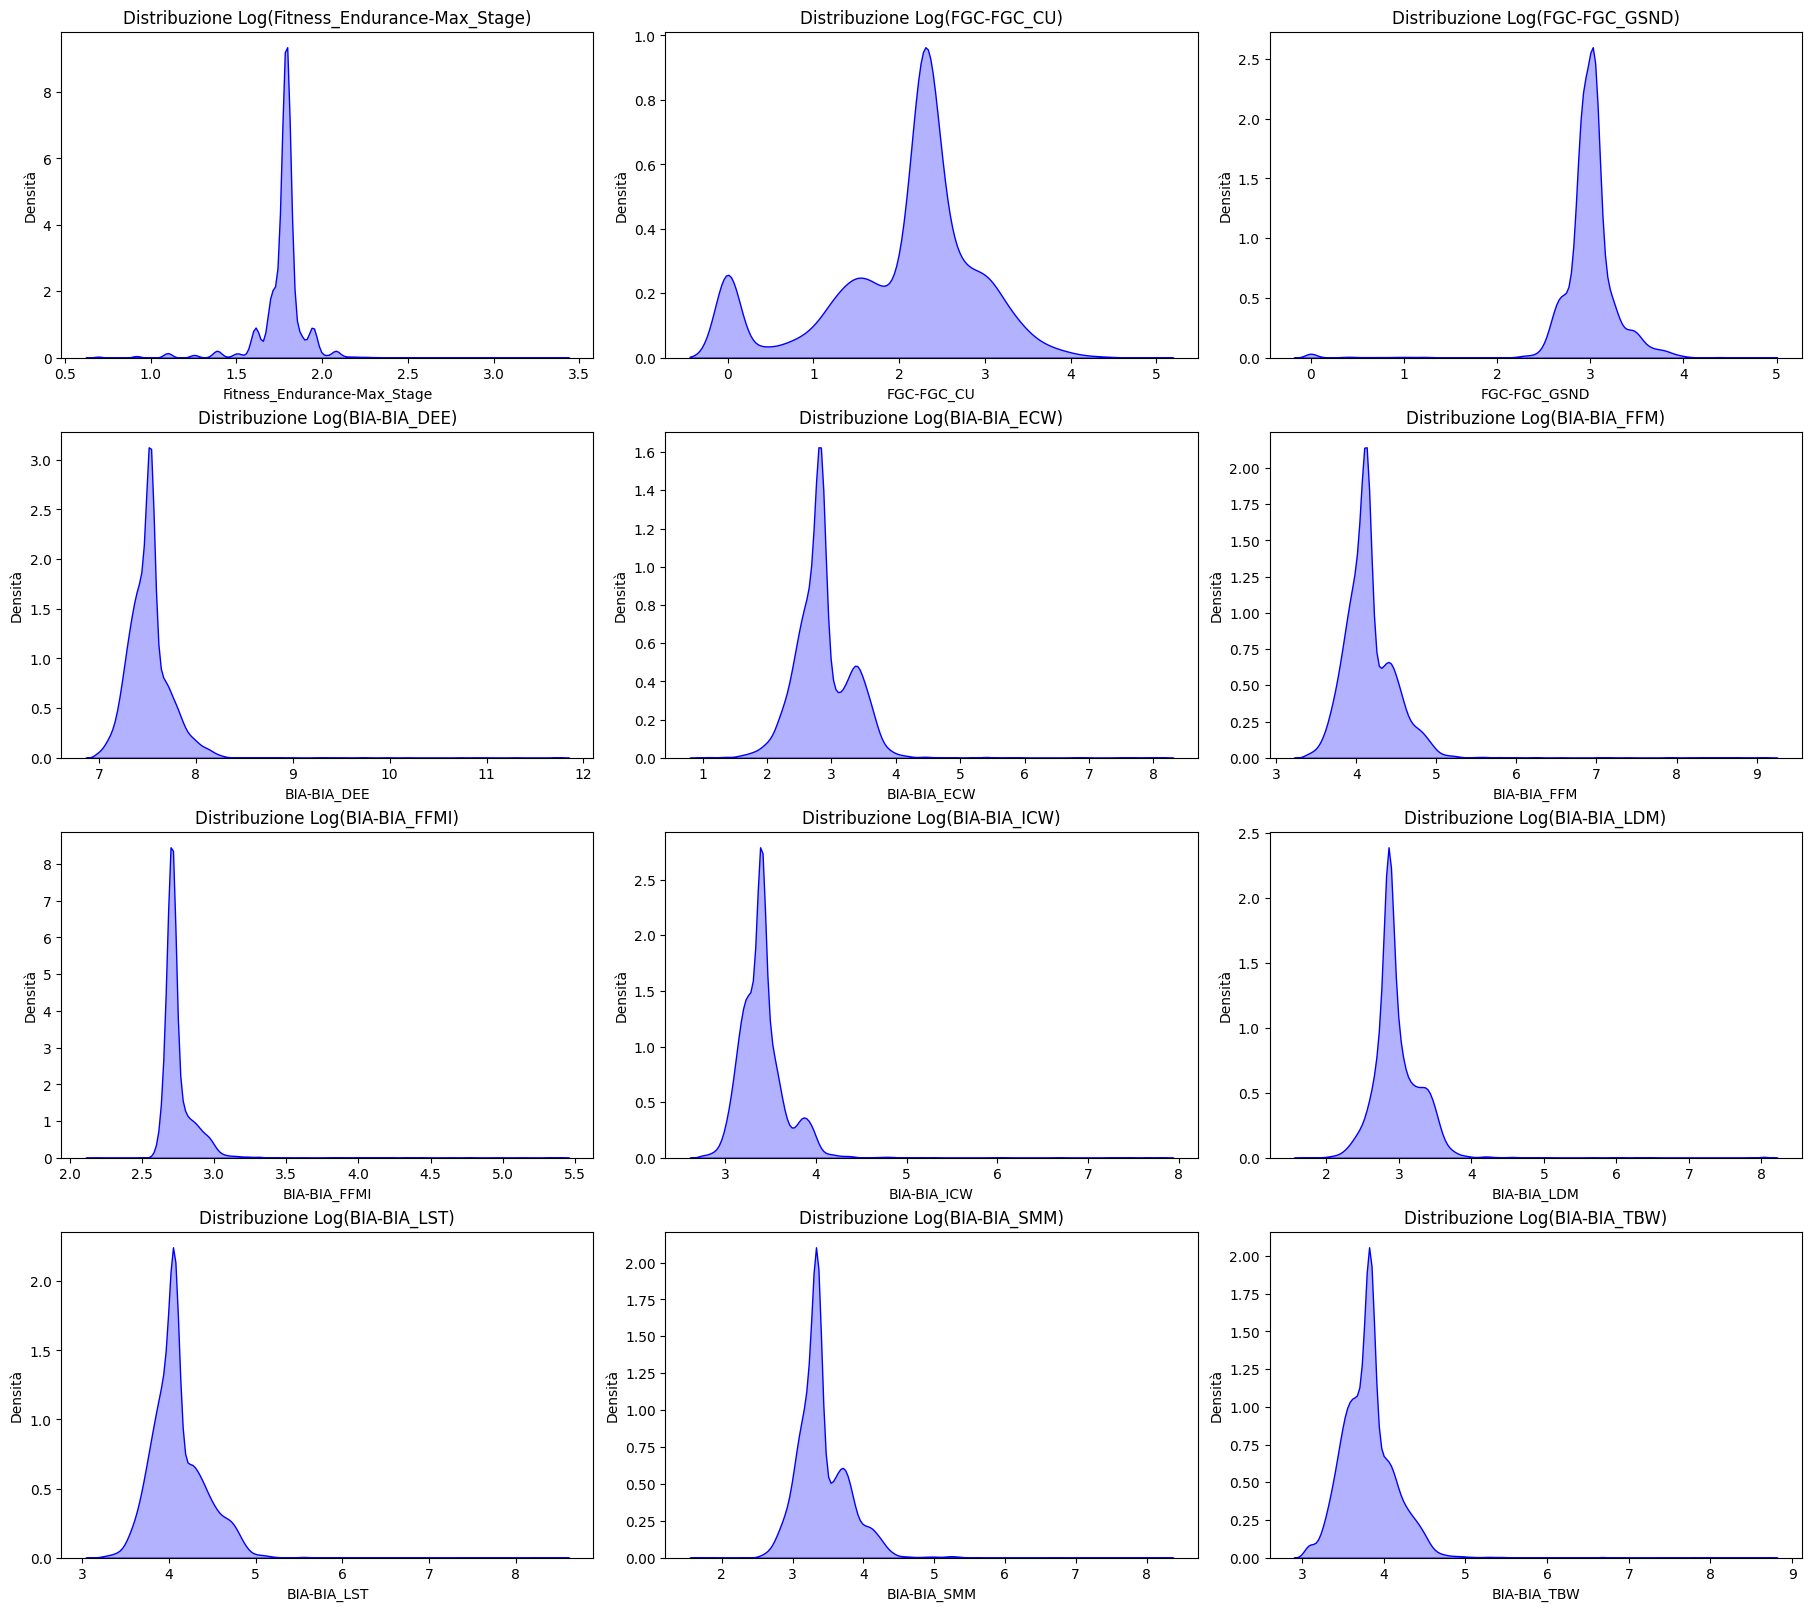

In [19]:
#controllo le distribuzioni dopo la trasformazione logaritmica usando un subplot
cols_to_log = ['Fitness_Endurance-Max_Stage','FGC-FGC_CU','FGC-FGC_GSND','BIA-BIA_DEE','BIA-BIA_ECW','BIA-BIA_FFM','BIA-BIA_FFMI','BIA-BIA_ICW','BIA-BIA_LDM','BIA-BIA_LST','BIA-BIA_SMM','BIA-BIA_TBW']
plt.figure(figsize=(12, 18))
ncols = 3
nrows = int(np.ceil(len(cols_to_log) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4), constrained_layout=True)
for idx, col in enumerate(cols_to_log):
    ax = axes[idx // ncols, idx % ncols]
    sns.kdeplot(df_final[col], fill=True, color='blue', alpha=0.3, ax=ax)
    ax.set_title(f'Distribuzione Log({col})')
    ax.set_xlabel(col)
    ax.set_ylabel('Densità')
for j in range(idx + 1, len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])  
plt.show()

In [20]:
#Droppo tutte le colonne Season
season_cols = [col for col in df_final.columns if 'Season' in col]
new_df_corr = df_final.drop(columns=season_cols)

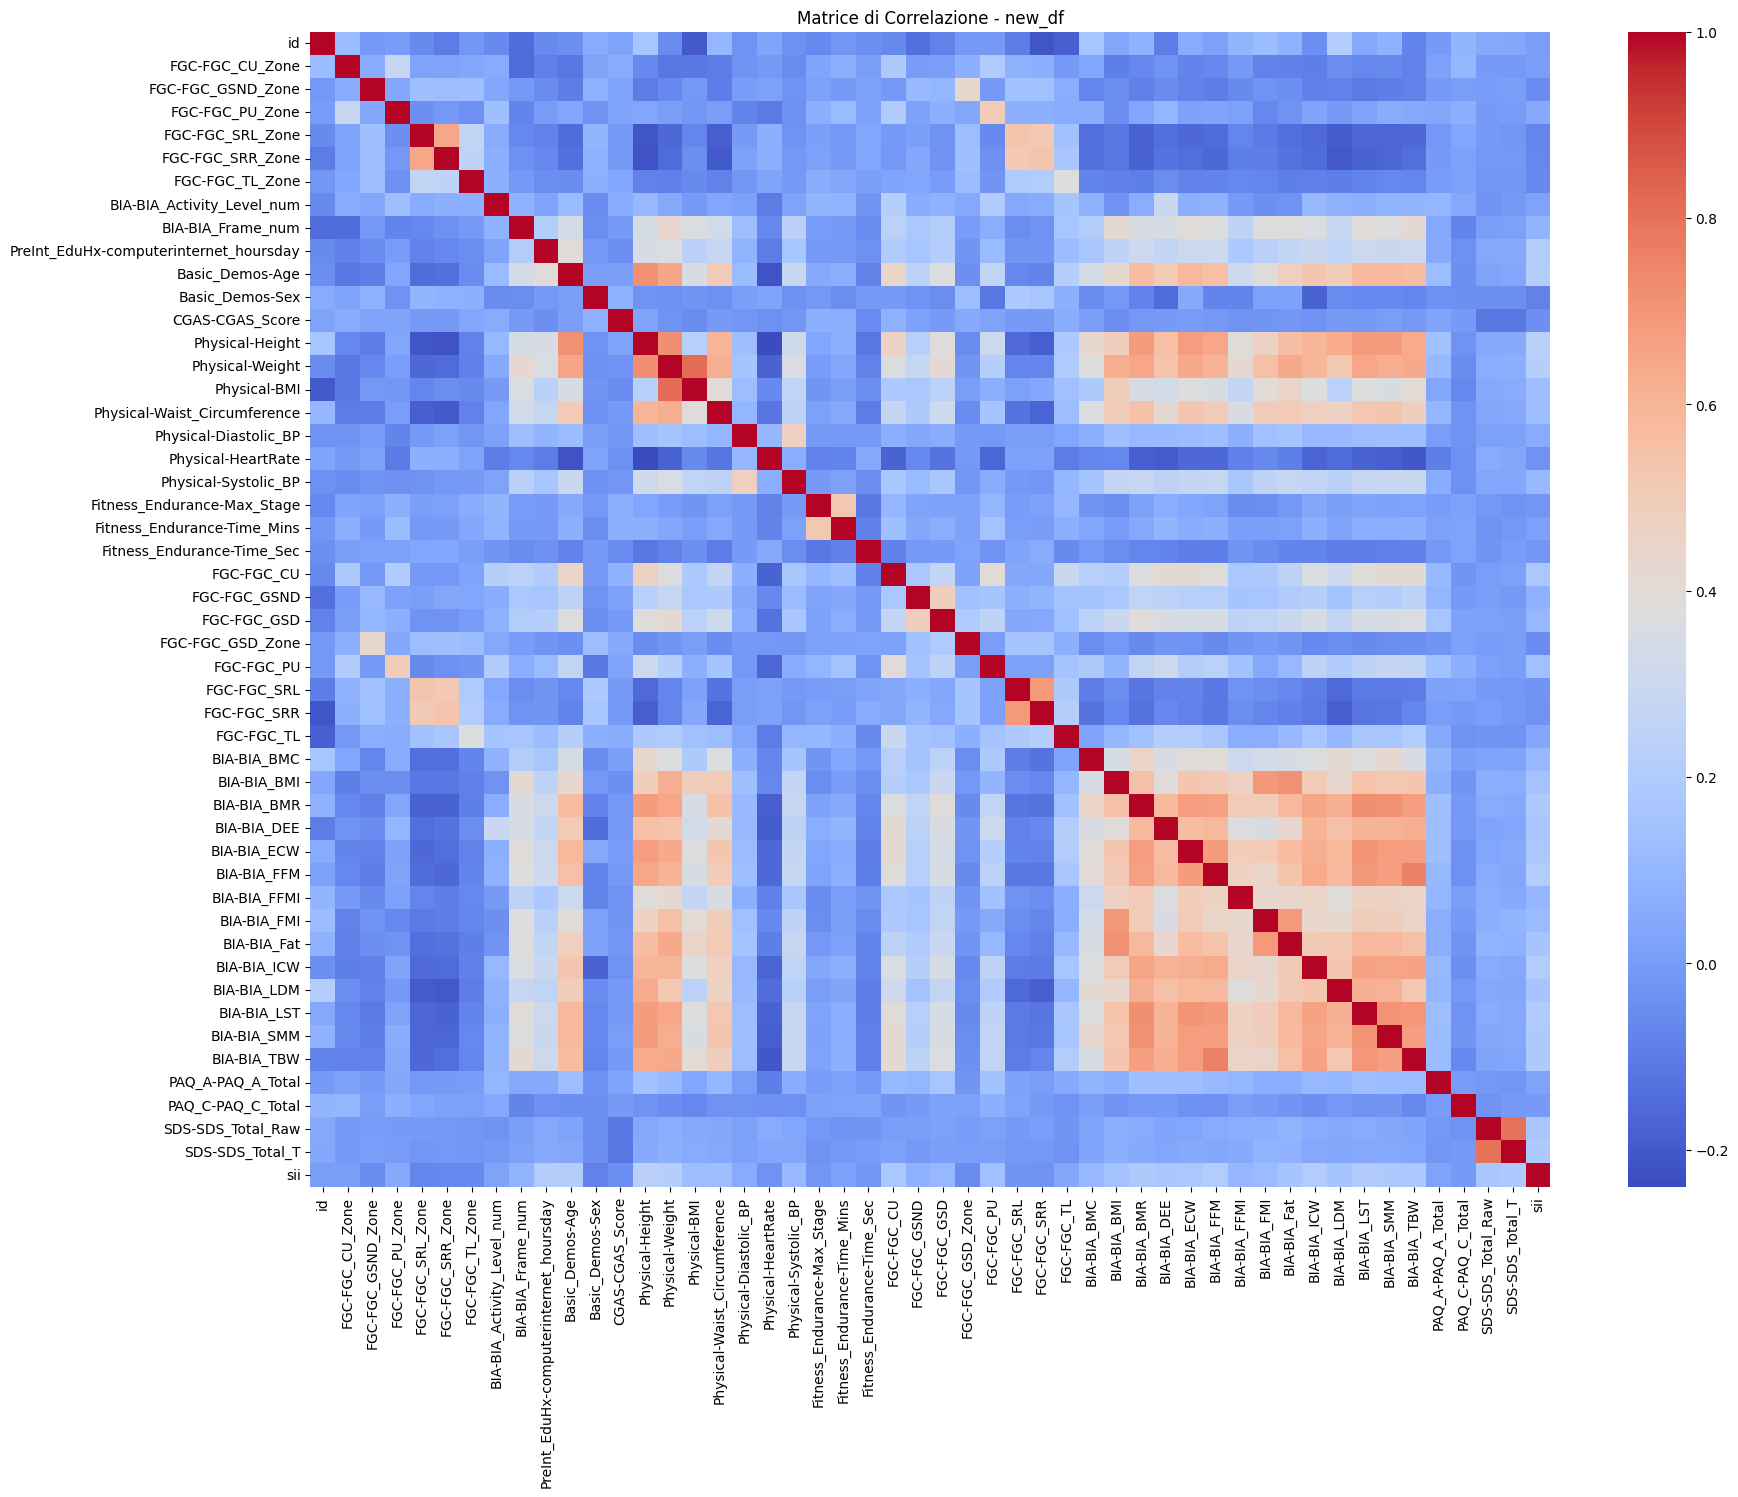

In [21]:
#Matrice delle correlazioni di new_df
plt.figure(figsize=(20, 15))
sns.heatmap(new_df_corr.corr(), fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matrice di Correlazione - new_df')
plt.show()

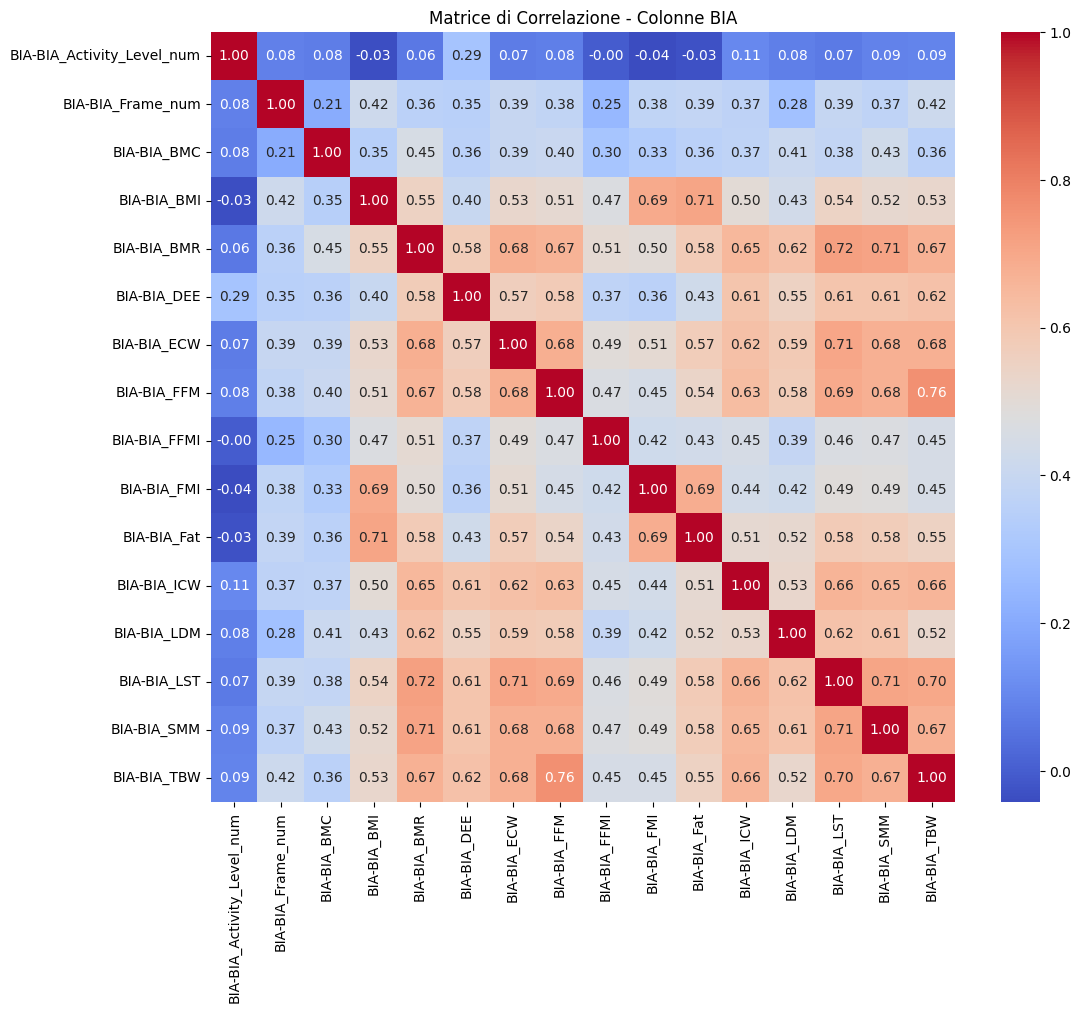

In [22]:
#considero solo le colonne BIA e faccio le matrici di correlazione
bia_cols = [col for col in new_df_corr.columns if col.startswith('BIA')]
new_df_bia = new_df_corr[bia_cols]
plt.figure(figsize=(12, 10))
sns.heatmap(new_df_bia.corr(), annot = True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matrice di Correlazione - Colonne BIA')
plt.show()

In [23]:
#Round delle colonne cols_to_log a 2 decimali
for col in cols_to_log:
    if (df_final[col] % 1 != 0).any(): 
        df_final[col] = df_final[col].round(2)

In [24]:
df_final.to_csv('cmi_internet_clean.csv', index=False)